# Titanic Survival Prediction

In this notebook we will predict whether a passenger survived the Titanic disaster using a **Decision Tree** and a **Random Forest** classifier.

Dataset is loaded from the local CSV file (originally downloaded from seaborn's built-in dataset).

In [2]:
import pandas as pd
df = pd.read_csv(r'C:\z_Learn\miraj_pandas\Machine Learning\decision_tree\titanic.csv')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.shape

(891, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.describe(include='object')

,sex,embarked,class,who,deck,embark_town,alive
count,891,889,891,891,203,889,891
unique,2,3,3,3,7,3,2
top,male,S,Third,man,C,Southampton,no
freq,577,644,491,537,59,644,549


In [7]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [8]:
print(df.duplicated().sum())

107


## EDA

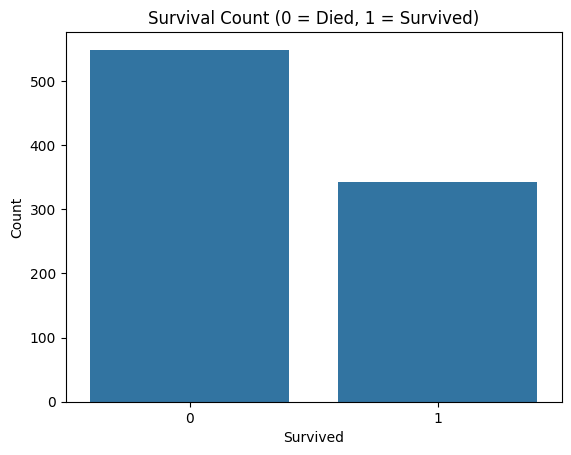

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='survived')
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

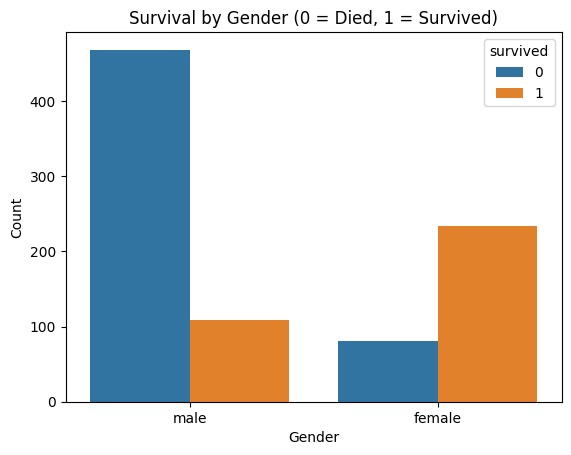

In [11]:
sns.countplot(data=df, x='sex', hue='survived')
plt.title('Survival by Gender (0 = Died, 1 = Survived)')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

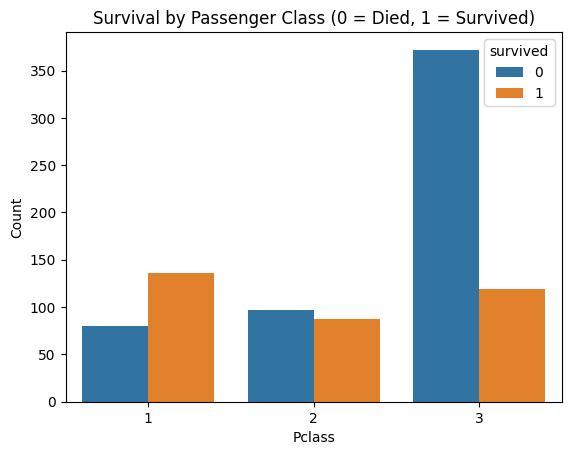

In [13]:
sns.countplot(data=df, x='pclass', hue='survived')
plt.title('Survival by Passenger Class (0 = Died, 1 = Survived)')
plt.xlabel('Pclass')
plt.ylabel('Count')
plt.show()

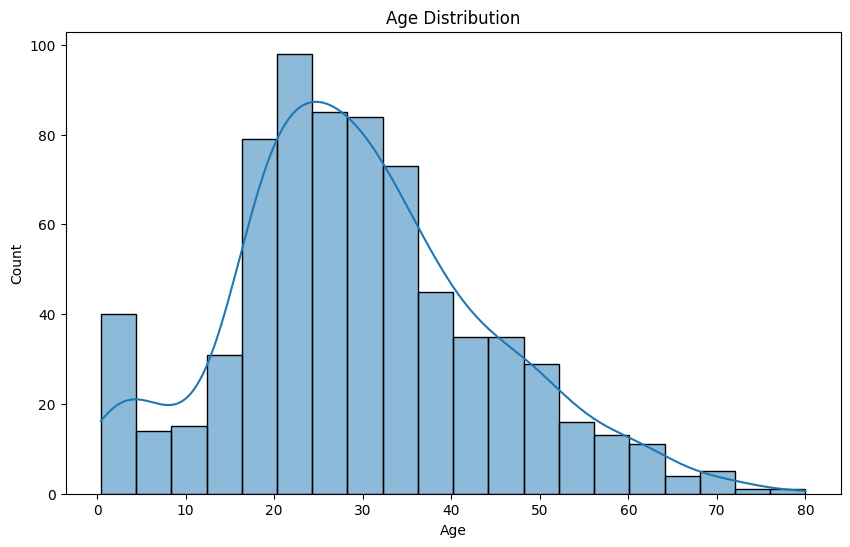

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df['age'].dropna(), kde=True, bins=20)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.show()

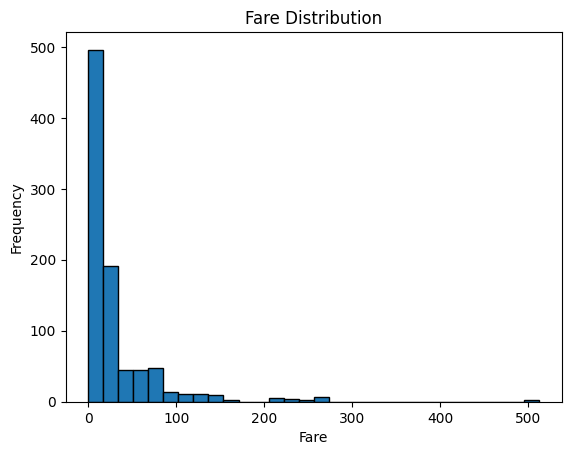

In [15]:
df['fare'].plot(kind='hist', bins=30, edgecolor='black')
plt.xlabel('Fare')
plt.title('Fare Distribution')
plt.show()

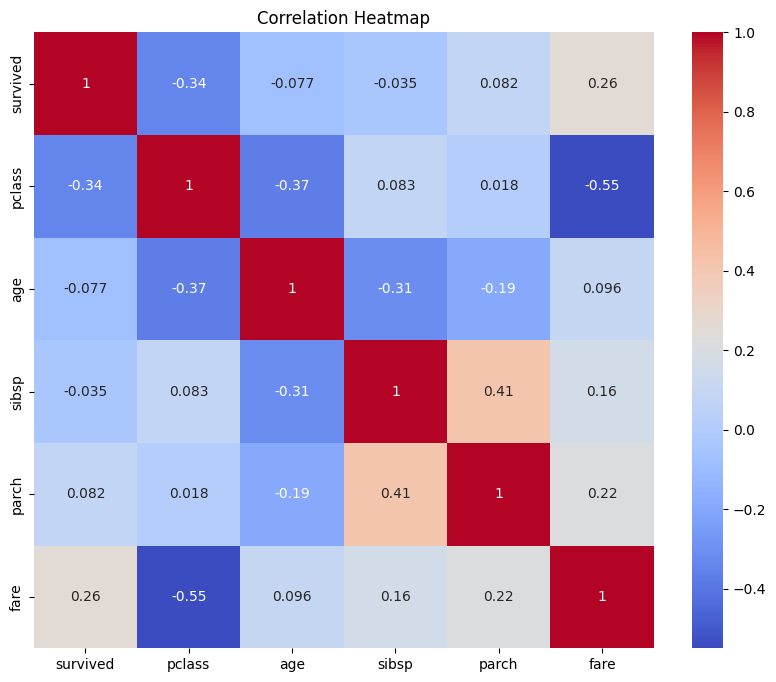

In [17]:
plt.figure(figsize=(10, 8))
num_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Data Preprocessing

The titanic dataset contains some columns that are duplicates or not useful for modelling:

- `class` is the same as `pclass` (just text instead of number)
- `alive` is the same as `survived` (target leakage)
- `who`, `adult_male`, `alone` are derived from other columns
- `deck` has 688 missing values out of 891 (too many to be useful)
- `embark_town` is the same as `embarked` (where the traveler mounted from.)

We will keep only the useful raw features: `survived`, `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`.

In [19]:
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


### Handling Missing Values

- `age` has 177 missing values → fill with **median** (robust to outliers/ less effected by outliers)
- `embarked` has 2 missing values → fill with **mode** (most frequent port)

In [20]:
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

## Splitting the data for training

In [21]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, train_size=0.7, test_size=0.3, random_state=1)
print('the shape of the train data set is : ', df_train.shape)
print('the shape of the test data set is : ', df_test.shape)

the shape of the train data set is :  (623, 8)
the shape of the test data set is :  (268, 8)


## Feature Encoding

- `sex`: binary categorical → convert to 0/1
- `embarked`: nominal categorical with 3 values (S, C, Q) → one-hot encode

In [22]:
df_train['sex'] = (df_train['sex'] == 'male').astype(int)
df_test['sex'] = (df_test['sex'] == 'male').astype(int)

In [23]:
df_train = pd.get_dummies(df_train, columns=['embarked'], drop_first=True)
df_test = pd.get_dummies(df_test, columns=['embarked'], drop_first=True)
df_train.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
114,0,3,0,17.0,0,0,14.4583,False,False
874,1,2,0,28.0,1,0,24.0000,False,False
76,0,3,1,28.0,0,0,7.8958,False,True
876,0,3,1,20.0,0,0,9.8458,False,True
674,0,2,1,28.0,0,0,0.0000,False,True


## Preparing the Input variable and Target Variable

In [24]:
y_train = df_train.pop('survived')
X_train = df_train

In [25]:
y_test = df_test.pop('survived')
X_test = df_test

In [26]:
X_train.head()

,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
114,3,0,17.0,0,0,14.4583,False,False
874,2,0,28.0,1,0,24.0000,False,False
76,3,1,28.0,0,0,7.8958,False,True
876,3,1,20.0,0,0,9.8458,False,True
674,2,1,28.0,0,0,0.0000,False,True


## Decision Tree Classifier

A **Decision Tree** is a flowchart-like model that splits the data based on feature values to make predictions.

### How it works

1. Start with the entire dataset at the **root node**.
2. At every node, the algorithm looks at all features and picks the **best split** that separates the classes most cleanly. The "best" is measured using a criterion like **Gini impurity** or **Entropy / Information Gain**.
3. The data is split into two child nodes based on that condition.
4. The process repeats recursively on each child node until a stopping condition is met (max depth reached, too few samples, or node is pure).
5. The final nodes are called **leaf nodes** and they hold the predicted class.

### Why use Decision Trees?

- Very **easy to interpret** and visualize.
- No need for feature scaling.
- Can handle both numerical and categorical data.
- Captures **non-linear** relationships.

### Disadvantages

- **Overfitting** is the biggest issue. A deep tree will memorize the training data and perform poorly on new data.
- Small changes in data can produce a very different tree (high variance).

In [27]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=1)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f'Decision Tree (default) Accuracy: {accuracy_dt:.2f}')

Decision Tree (default) Accuracy: 0.76


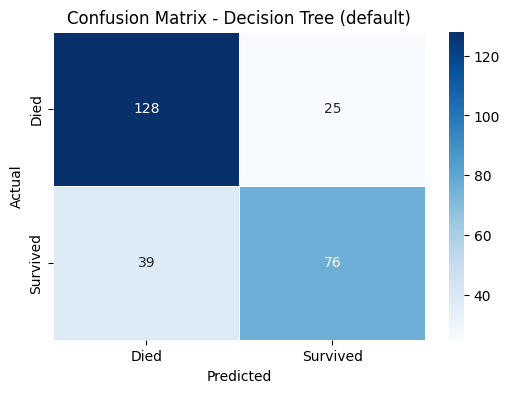

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'],
            linewidths=0.5)
plt.title('Confusion Matrix - Decision Tree (default)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

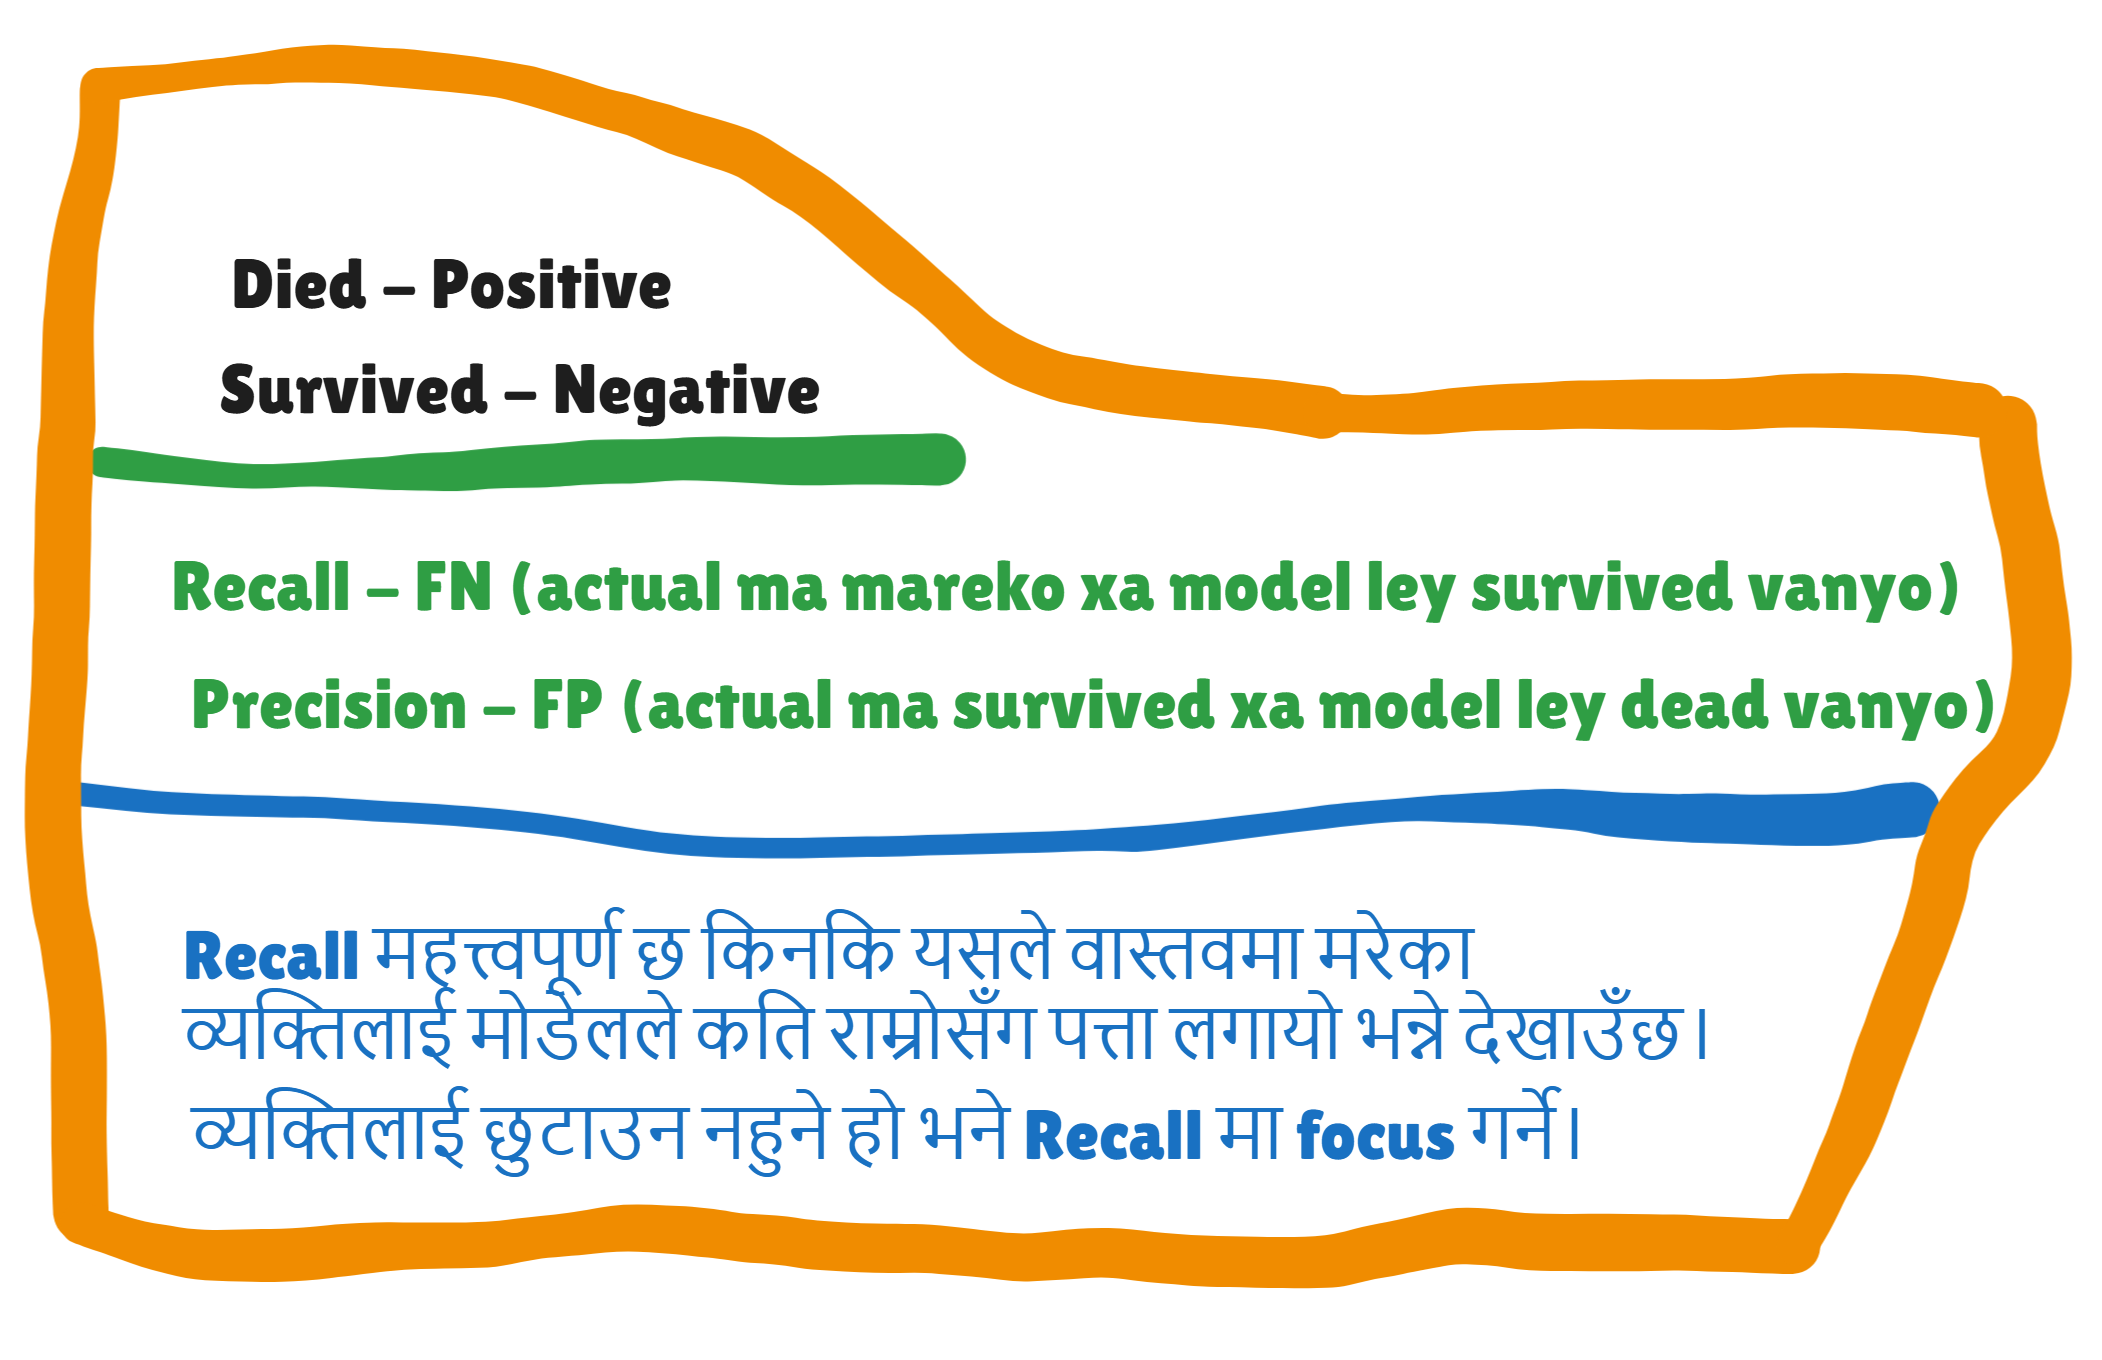

In [30]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.77      0.84      0.80       153
           1       0.75      0.66      0.70       115

    accuracy                           0.76       268
   macro avg       0.76      0.75      0.75       268
weighted avg       0.76      0.76      0.76       268



`"Since the objective is to correctly identify passengers who died, we focus on Class 0. The model achieved a recall of 84%, meaning it correctly identified 84% of actual deaths." `

## Tuning the Decision Tree: `max_depth` and `min_samples_leaf`

The default Decision Tree grows until every leaf is pure → it **overfits**. We control this with hyperparameters.

### `max_depth`

- The **maximum number of levels** the tree is allowed to grow.
- A small `max_depth` (eg. 3) creates a simple tree → may **underfit**.
- A large `max_depth` (or `None`) lets the tree grow fully → may **overfit**.
- Typical values to try: 3, 5, 7, 10.

### `min_samples_leaf`

- The **minimum number of samples** that must be present in a leaf node.
- If a split would create a leaf with fewer samples than this, the split is **not allowed**.
- A small value (eg. 1) → tree can create leaves for very few samples → **overfits**.
- A large value (eg. 20) → tree is forced to generalize → may **underfit**.
- Typical values to try: 5, 10, 20.

### Intuition

> Both `max_depth` and `min_samples_leaf` are forms of **pre-pruning**. They stop the tree from growing too deep so that it generalizes better to unseen data.

In [32]:
dt_tuned = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=1)
dt_tuned.fit(X_train, y_train)
y_pred_dt_tuned = dt_tuned.predict(X_test)

accuracy_dt_tuned = accuracy_score(y_test, y_pred_dt_tuned)
print(f'Decision Tree (max_depth=5, min_samples_leaf=10) Accuracy: {accuracy_dt_tuned:.2f}')

Decision Tree (max_depth=5, min_samples_leaf=10) Accuracy: 0.77


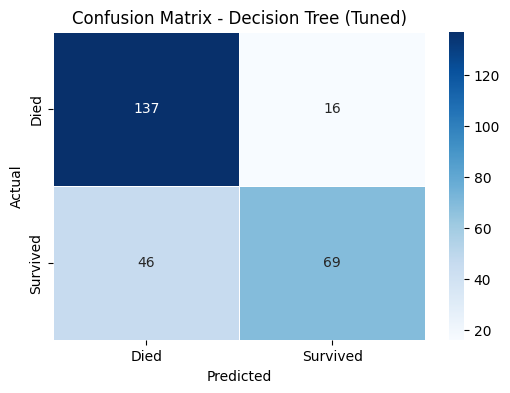

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_dt_tuned)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'],
            linewidths=0.5)
plt.title('Confusion Matrix - Decision Tree (Tuned)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [37]:
print(classification_report(y_test, y_pred_dt_tuned))

              precision    recall  f1-score   support

           0       0.75      0.90      0.82       153
           1       0.81      0.60      0.69       115

    accuracy                           0.77       268
   macro avg       0.78      0.75      0.75       268
weighted avg       0.78      0.77      0.76       268



## Random Forest Classifier

A **Random Forest** is an **ensemble** of many Decision Trees that vote together to make a prediction. It is one of the most popular and reliable algorithms in classical ML.

### How it works

1. **Bootstrap sampling (Bagging):** From the original training data of size `N`, create many random samples of size `N` **with replacement**. Each sample is used to train one tree.
2. **Random feature selection:** At every split inside a tree, only a **random subset of features** is considered (instead of all features). This is what makes the forest *random*.
3. **Train many trees:** Each tree is grown independently on its bootstrap sample. Trees are usually grown deep without much pruning.
4. **Voting / Averaging:**
   - For **classification**: each tree predicts a class, and the forest picks the class with the **majority vote**.
   - For **regression**: the forest takes the **average** of all tree predictions.

### Why is it better than a single Decision Tree?

- A single tree has **high variance** — it overfits to the training data.
- By averaging many trees that were each trained on slightly different data and different features, the **errors cancel out** and the variance drops dramatically.
- This is called the **wisdom of the crowd** — a group of weak, diverse learners can be a strong learner.

### Key hyperparameters

- `n_estimators`: number of trees in the forest. More trees = more stable predictions but slower. Common: 100, 200, 500.
- `max_depth`: max depth of each individual tree (same as Decision Tree).
- `min_samples_leaf`: minimum samples per leaf (same as Decision Tree).
- `max_features`: number of features to consider at each split. Default is `sqrt(n_features)` for classification.

### Advantages

- Much better accuracy than a single Decision Tree.
- Handles overfitting well by design.
- Works well on both numerical and categorical features.
- Gives **feature importance** scores out of the box.

### Disadvantages

- Slower to train and predict than a single tree.
- Harder to interpret (it is a black box of 100s of trees).

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100,
                            max_depth=5,
                            min_samples_leaf=5,
                            random_state=1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [39]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {accuracy_rf:.2f}')

Random Forest Accuracy: 0.78


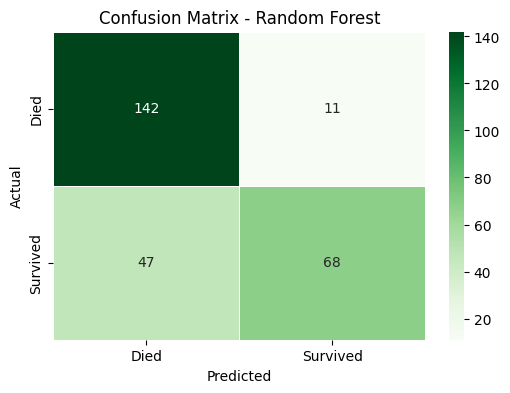

In [40]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'],
            linewidths=0.5)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [41]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.75      0.93      0.83       153
           1       0.86      0.59      0.70       115

    accuracy                           0.78       268
   macro avg       0.81      0.76      0.77       268
weighted avg       0.80      0.78      0.77       268



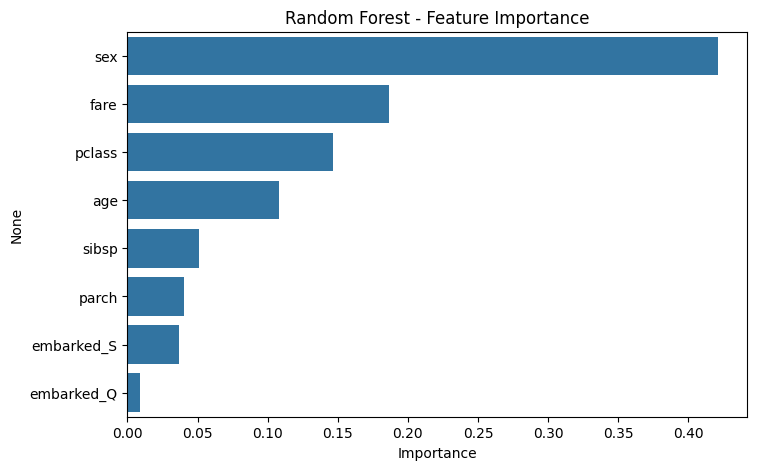

In [42]:
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Random Forest - Feature Importance')
plt.xlabel('Importance')
plt.show()

### Conclusion

- The **default Decision Tree** overfits because it grows until every leaf is pure.
- After tuning `max_depth` and `min_samples_leaf`, the tree generalizes better and accuracy improves.
- The **Random Forest** usually beats both because it averages many decorrelated trees, reducing variance.
- From the feature importance plot we can see that `sex`, `fare`, `age`, and `pclass` are the strongest predictors of survival — which makes historical sense (women and higher-class passengers were more likely to be rescued first).